In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, \
    max_error, mean_poisson_deviance, mean_gamma_deviance, mean_tweedie_deviance, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt
import optuna
from prophet import Prophet


### Reading the dataset as CSV

In [3]:
df = pd.read_csv('../input/electricity-load-forecasting/continuous dataset.csv')
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


### Splitting the dataset into train and test sets

In [4]:
train_df = df[df['datetime'] < "2019-01-01"]
train_df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [5]:
test_df = df[df['datetime'] >= "2019-01-01"]
test_df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
35015,2019-01-01 00:00:00,1027.9238,24.885645,0.017164,0.007330,22.597570,23.682520,0.016592,0.018089,12.133071,22.143457,0.016005,0.072266,6.110409,1,1,0
35016,2019-01-01 01:00:00,1006.3692,24.839471,0.017123,0.008972,23.223214,23.519159,0.016452,0.014172,12.098985,22.066034,0.015872,0.079041,6.145190,1,1,0
35017,2019-01-01 02:00:00,990.4364,24.862939,0.017205,0.011501,23.223043,23.402002,0.016335,0.012352,12.282677,21.980127,0.015694,0.080963,6.233335,1,1,0
35018,2019-01-01 03:00:00,975.8917,24.886011,0.017333,0.012527,22.834583,23.300073,0.016196,0.007969,12.509328,21.886011,0.015506,0.080414,6.368042,1,1,0
35019,2019-01-01 04:00:00,949.1626,24.932092,0.017439,0.012455,22.174321,23.166467,0.016096,0.007296,11.912222,21.838342,0.015379,0.078094,6.269188,1,1,0


### Feature Engineering

In [ ]:
windows = [12, 24, 128]
for column in train_df.columns:
    if column == 'nat_demand':
        for window in windows:
            train_df[f"{column}_lag_{window}"] = train_df[column].shift(window)
            train_df[f"{column}_ma_mean{window}"] = train_df[column].rolling(window).mean()
            train_df[f"{column}_std_std{window}"] = train_df[column].rolling(window).std()
            train_df[f"{column}_ewm_std{window}"] = train_df[column].ewm(window).std()
            train_df[f"{column}_ewm_mean{window}"] = train_df[column].ewm(window).mean()
            
            
    if column != 'datetime' and column != 'holiday' and column != 'school' and column != 'Holiday_ID' and column != 'nat_demand':
        for window in windows:
            train_df[f"{column}_lag_{window}"] = train_df[column].shift(window)
            train_df[f"{column}_ma_mean{window}"] = train_df[column].rolling(window).mean()
            train_df[f"{column}_std_std{window}"] = train_df[column].rolling(window).std()
            train_df[f"{column}_ewm_std{window}"] = train_df[column].ewm(window).std()
            train_df[f"{column}_ewm_mean{window}"] = train_df[column].ewm(window).mean()
            train_df[f"{column}_min_max{window}"] = (train_df[column] -train_df[column].rolling(window).min()) / (train_df[column].rolling(window).max() - train_df[column].rolling(window).min())
            train_df[f"{column}_median{window}"] = train_df[column].rolling(window).median()
            train_df[f"{column}_skew{window}"] = train_df[column].rolling(window).skew()
            train_df[f"{column}_kurt{window}"] = train_df[column].rolling(window).kurt()
            train_df[f"{column}_p50{window}"] = train_df[column].rolling(window).quantile(0.5)

train_df.dropna(inplace=True)

In [7]:
train_df

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,W2M_dav_lag_128,W2M_dav_ma_mean128,W2M_dav_std_std128,W2M_dav_ewm_std128,W2M_dav_ewm_mean128,W2M_dav_min_max128,W2M_dav_median128,W2M_dav_skew128,W2M_dav_kurt128,W2M_dav_p50128
128,2015-01-08 09:00:00,1275.1120,27.571802,0.016819,0.026474,33.521500,26.884302,0.017131,0.062561,18.893116,...,5.364148,6.199112,1.491481,1.390388,6.439521,0.973497,6.394866,-0.567548,-0.519360,6.394866
129,2015-01-08 10:00:00,1348.9510,28.399377,0.016773,0.025772,33.816953,27.993127,0.017017,0.058289,19.903031,...,5.572471,6.220771,1.502398,1.397702,6.462729,0.982404,6.464252,-0.575322,-0.525737,6.464252
130,2015-01-08 11:00:00,1365.6284,29.004724,0.016819,0.031982,33.338703,28.785974,0.017048,0.055099,19.899943,...,5.871184,6.240072,1.513699,1.404431,6.485517,0.981865,6.485280,-0.579291,-0.539667,6.485280
131,2015-01-08 12:00:00,1343.4717,29.328638,0.016871,0.048721,32.322581,29.297388,0.017054,0.044006,19.667262,...,5.883621,6.260305,1.526154,1.412813,6.509520,1.000000,6.503291,-0.580459,-0.552839,6.503291
132,2015-01-08 13:00:00,1371.5959,29.372705,0.016870,0.065063,31.365933,29.528955,0.016962,0.046646,19.495408,...,5.611724,6.284000,1.539492,1.423564,6.535190,1.000000,6.522611,-0.582098,-0.556282,6.522611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35010,2018-12-31 19:00:00,1278.6240,25.926416,0.017542,0.006657,23.312495,24.371729,0.016635,0.002964,10.364903,...,6.980621,4.765239,1.480682,1.519725,4.903959,0.867298,4.849127,-0.864839,0.903443,4.849127
35011,2018-12-31 20:00:00,1241.6289,25.626184,0.017188,0.007753,23.396554,24.055872,0.016654,0.005663,10.329677,...,6.977380,4.760650,1.474671,1.519445,4.915479,0.865830,4.849127,-0.882278,0.927637,4.849127
35012,2018-12-31 21:00:00,1193.0323,25.398706,0.017038,0.003750,23.285532,23.875269,0.016672,0.007523,10.568211,...,7.005403,4.753688,1.466068,1.517206,4.924772,0.824538,4.849127,-0.905845,0.965076,4.849127
35013,2018-12-31 22:00:00,1137.6514,25.179926,0.017070,0.002913,22.767433,23.804926,0.016696,0.013668,11.376140,...,7.024324,4.746265,1.456857,1.514685,4.933682,0.818517,4.849127,-0.931936,1.005247,4.849127


In [ ]:
windows = [12, 24, 128]
for column in test_df.columns:
    if column == 'nat_demand':
        for window in windows:
        
            test_df[f"{column}_lag_{window}"] = test_df[column].shift(window)
            test_df[f"{column}_lag_{window}"] = test_df[column].shift(window)
            test_df[f"{column}_ma_mean{window}"] = test_df[column].rolling(window).mean()
            test_df[f"{column}_std_std{window}"] = test_df[column].rolling(window).std()
            test_df[f"{column}_ewm_std{window}"] = test_df[column].ewm(window).std()
            test_df[f"{column}_ewm_mean{window}"] = test_df[column].ewm(window).mean()
            
    if column != 'datetime' and column != 'holiday' and column != 'school' and column != 'Holiday_ID' and column != 'nat_demand':
        for window in windows:
            test_df[f"{column}_lag_{window}"] = test_df[column].shift(window)
            test_df[f"{column}_ma_mean{window}"] = test_df[column].rolling(window).mean()
            test_df[f"{column}_std_std{window}"] = test_df[column].rolling(window).std()
            test_df[f"{column}_ewm_std{window}"] = test_df[column].ewm(window).std()
            test_df[f"{column}_ewm_mean{window}"] = test_df[column].ewm(window).mean()
            test_df[f"{column}_min_max{window}"] = (test_df[column] -test_df[column].rolling(window).min()) / (test_df[column].rolling(window).max() - test_df[column].rolling(window).min())
            test_df[f"{column}_median{window}"] = test_df[column].rolling(window).median()
            test_df[f"{column}_skew{window}"] = test_df[column].rolling(window).skew()
            test_df[f"{column}_kurt{window}"] = test_df[column].rolling(window).kurt()
            test_df[f"{column}_p50{window}"] = test_df[column].rolling(window).quantile(0.5)

test_df.dropna(inplace=True)

In [9]:
test_df

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,W2M_dav_lag_128,W2M_dav_ma_mean128,W2M_dav_std_std128,W2M_dav_ewm_std128,W2M_dav_ewm_mean128,W2M_dav_min_max128,W2M_dav_median128,W2M_dav_skew128,W2M_dav_kurt128,W2M_dav_p50128
35143,2019-01-06 08:00:00,1010.4562,26.479791,0.016606,0.024277,25.745778,25.511041,0.016995,0.017456,11.846568,...,6.110409,4.575148,1.511192,1.469350,4.434729,0.584200,4.869911,-0.794132,0.105066,4.869911
35144,2019-01-06 09:00:00,1050.7971,27.411096,0.016399,0.031555,27.262736,27.270471,0.017185,0.014236,14.011013,...,6.145190,4.560622,1.504904,1.460425,4.432914,0.540201,4.853817,-0.783848,0.116907,4.853817
35145,2019-01-06 10:00:00,1100.5710,28.260309,0.016414,0.027863,27.282461,28.541559,0.017299,0.011993,14.315570,...,6.233335,4.543838,1.498066,1.452007,4.428696,0.507997,4.842220,-0.771877,0.126300,4.842220
35146,2019-01-06 11:00:00,1154.8653,28.903589,0.016452,0.027283,26.760379,29.512964,0.017390,0.011295,14.150185,...,6.368042,4.523386,1.490818,1.445092,4.420503,0.454270,4.822929,-0.757241,0.127051,4.822929
35147,2019-01-06 12:00:00,1168.6314,29.288812,0.016428,0.026230,26.304043,30.148187,0.017473,0.012177,13.900855,...,6.269188,4.499522,1.487095,1.442391,4.406005,0.368330,4.788671,-0.732426,0.098339,4.788671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,...,1.519354,2.434515,0.858886,1.080783,2.716574,0.585725,2.437952,-0.269729,-0.461723,2.437952
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,...,2.021437,2.438377,0.858125,1.076730,2.715018,0.605266,2.450098,-0.283265,-0.447758,2.450098
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,...,2.240761,2.442752,0.858537,1.072575,2.715682,0.683506,2.457710,-0.297688,-0.446453,2.457710
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,...,1.974162,2.451845,0.859699,1.069054,2.718957,0.776166,2.463881,-0.323192,-0.444398,2.463881


In [10]:
X_train, X_test = train_df.drop(columns = ['nat_demand','datetime']), test_df.drop(columns = ['nat_demand','datetime'])
y_train, y_test = train_df['nat_demand'], test_df['nat_demand']

### Feature Scaling

In [11]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training the XGBoost Model

In [16]:
dtrain = xgb.DMatrix(X_train_scaled, label=y_train, feature_names=X_train.columns.to_list())
dtest = xgb.DMatrix(X_test_scaled, label=y_test, feature_names=X_test.columns.to_list())

In [23]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'gpu_hist',
        'gpu_id': 0,
        'eta': trial.suggest_float('eta', 0.001, 0.5),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'lambda': trial.suggest_float('lambda', 0.0, 2.0),
        'alpha': trial.suggest_float('alpha', 0.0, 2.0),
        'nthread': -1,
        'seed': 42
    }

    num_round = 100
    model = xgb.train(params, dtrain, num_round)

    predictions = model.predict(dtest)
    rmse = mean_squared_error(y_test, predictions, squared=False)
    return rmse

In [24]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

[I 2025-05-31 12:43:18,611] A new study created in memory with name: no-name-79fa2fd0-dd91-4ef1-ba8e-79b62cab663a
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [12:43:18] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [12:43:19] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
[I 2025-05-31 12:43:19,328] Trial 0 finished with value: 52.41678393520549 and parameters: {'eta': 0.17487310301355946, 'max_depth': 7, 'min_child_weight': 15.584620418360696, 'subsample': 0.6916847992884484, 'cols

In [25]:
best_params = study.best_params
best_params['tree_method'] = 'gpu_hist'
best_params['gpu_id'] = 0
print("Best params:", best_params)
xgb_best_params = best_params

Best params: {'eta': 0.06689354561887709, 'max_depth': 8, 'min_child_weight': 7.341546134667743, 'subsample': 0.616352492473783, 'colsample_bytree': 0.9649391752637607, 'gamma': 3.00093646589738, 'lambda': 0.2680198449960511, 'alpha': 1.4323321140328622, 'tree_method': 'gpu_hist', 'gpu_id': 0}


In [26]:
xgb_model = xgb.train(best_params, dtrain, 100)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [12:47:03] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


In [43]:
predictions = xgb_predictions = xgb_model.predict(dtest)

### Performance of XGBoost Model

In [28]:
rmse_test = mean_squared_error(y_test, predictions, squared=False)
mae_test = mean_absolute_error(y_test, predictions)
r2_test = r2_score(y_test, predictions)
explained_variance = explained_variance_score(y_test, predictions)
max_err = max_error(y_test, predictions)
poisson_deviance = mean_poisson_deviance(y_test, predictions)
gamma_deviance = mean_gamma_deviance(y_test, predictions)
tweedie_deviance = mean_tweedie_deviance(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
print(f"RMSE on test data: {rmse_test}")
print(f"MAE on test data: {mae_test}")
print("Mean Absolute Percentage Error:", mape)
print(f"R-squared on test data: {r2_test}")
print(f"Explained Variance on test data: {explained_variance}")
print(f"Max Error on test data: {max_err}")
print(f"Mean Poisson Deviance on test data: {poisson_deviance}")
print(f"Mean Gamma Deviance on test data: {gamma_deviance}")
print(f"Mean Tweedie Deviance on test data: {tweedie_deviance}")

RMSE on test data: 50.26961836187714
MAE on test data: 32.415590364275594
Mean Absolute Percentage Error: 0.028550712169925087
R-squared on test data: 0.9285874727333966
Explained Variance on test data: 0.9325322647385964
Max Error on test data: 1175.044560546875
Mean Poisson Deviance on test data: 2.229468107051996
Mean Gamma Deviance on test data: 0.0021934121445095103
Mean Tweedie Deviance on test data: 2527.0345302487754


### Sensitivity test of XGBoost Model

In [33]:
def remove_random_data(X, y, removal_percentage=0.1):
    num_points_to_remove = int(len(X) * removal_percentage)
    indices_to_remove = np.random.choice(len(X), num_points_to_remove, replace=False)

    X_filtered = np.delete(X, indices_to_remove, axis=0)
    y_filtered = np.delete(y, indices_to_remove)

    return X_filtered, y_filtered

removal_rates = list(range(10, 51, 10))
rmse_scores = []
mae_scores = []
r2_scores = []
explained_variance_scores = []
max_err_scores = []
poisson_deviance_scores = []
gamma_deviance_scores = []
tweedie_deviance_scores = []
mape_scores = []

for rate in removal_rates:
    X_train_filtered, y_train_filtered = remove_random_data(X_train_scaled, y_train.values, removal_percentage=rate / 100)
    X_test_filtered, y_test_filtered = remove_random_data(X_test_scaled, y_test.values, removal_percentage=rate / 100)

    dtrain_filtered = xgb.DMatrix(X_train_filtered, label=y_train_filtered, feature_names=X_train.columns.to_list())

    num_round = 100
    model_filtered = xgb.train(best_params, dtrain_filtered, num_round)

    dtest_filtered = xgb.DMatrix(X_test_filtered, label=y_test_filtered, feature_names=X_test.columns.to_list())

    predictions_filtered = model_filtered.predict(dtest_filtered)

    rmse_scores.append(mean_squared_error(y_test_filtered, predictions_filtered, squared=False))
    mae_scores.append(mean_absolute_error(y_test_filtered, predictions_filtered))
    r2_scores.append(r2_score(y_test_filtered, predictions_filtered))
    explained_variance_scores.append(explained_variance_score(y_test_filtered, predictions_filtered))
    max_err_scores.append(max_error(y_test_filtered, predictions_filtered))
    poisson_deviance_scores.append(mean_poisson_deviance(y_test_filtered, predictions_filtered))
    gamma_deviance_scores.append(mean_gamma_deviance(y_test_filtered, predictions_filtered))
    tweedie_deviance_scores.append(mean_tweedie_deviance(y_test_filtered, predictions_filtered))
    mape_scores.append(mean_absolute_percentage_error(y_test_filtered, predictions_filtered))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [12:50:14] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [12:50:16] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [12:50:16] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserW

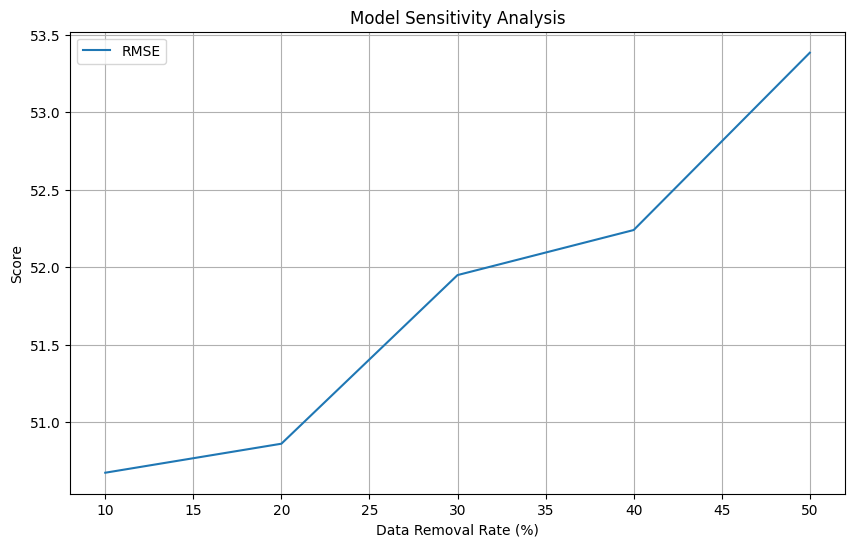

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(removal_rates, rmse_scores, label='RMSE')
# plt.plot(removal_rates, mae_scores, label='MAE')
# plt.plot(removal_rates, r2_scores, label='R-squared')
# plt.plot(removal_rates, explained_variance_scores, label='Explained Variance')
# plt.plot(removal_rates, max_err_scores, label='Max Error')
# plt.plot(removal_rates, poisson_deviance_scores, label='Poisson Deviance')
# plt.plot(removal_rates, gamma_deviance_scores, label='Gamma Deviance')
# plt.plot(removal_rates, tweedie_deviance_scores, label='Tweedie Deviance')
# plt.plot(removal_rates, mape_scores, label='MAPE')

plt.title('Model Sensitivity Analysis')
plt.xlabel('Data Removal Rate (%)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

### Training the Prophet Model

In [38]:
prophet_train_df = pd.DataFrame({'ds': train_df['datetime'], 'y': train_df['nat_demand']})

prophet_model = Prophet()

num_columns2 = len(train_df.columns)
for i in range(2, num_columns2):  
    regressor_name = train_df.columns[i]
    prophet_model.add_regressor(regressor_name)
    prophet_train_df[regressor_name] = train_df[regressor_name]

prophet_model.fit(prophet_train_df)

prophet_future = pd.DataFrame({'ds': test_df['datetime']})

for i in range(2, num_columns2):
    regressor_name = train_df.columns[i]
    prophet_future[regressor_name] = test_df[regressor_name]

prophet_forecast = prophet_model.predict(prophet_future)
prophet_predictions = prophet_forecast['yhat']

/tmp/ipykernel_35/340637505.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prophet_train_df[regressor_name] = train_df[regressor_name]
/tmp/ipykernel_35/340637505.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prophet_train_df[regressor_name] = train_df[regressor_name]
/tmp/ipykernel_35/340637505.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To 

In [40]:
prophet_future

,ds,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,W2M_dav_lag_128,W2M_dav_ma_mean128,W2M_dav_std_std128,W2M_dav_ewm_std128,W2M_dav_ewm_mean128,W2M_dav_min_max128,W2M_dav_median128,W2M_dav_skew128,W2M_dav_kurt128,W2M_dav_p50128
35143,2019-01-06 08:00:00,26.479791,0.016606,0.024277,25.745778,25.511041,0.016995,0.017456,11.846568,23.378229,...,6.110409,4.575148,1.511192,1.469350,4.434729,0.584200,4.869911,-0.794132,0.105066,4.869911
35144,2019-01-06 09:00:00,27.411096,0.016399,0.031555,27.262736,27.270471,0.017185,0.014236,14.011013,24.934534,...,6.145190,4.560622,1.504904,1.460425,4.432914,0.540201,4.853817,-0.783848,0.116907,4.853817
35145,2019-01-06 10:00:00,28.260309,0.016414,0.027863,27.282461,28.541559,0.017299,0.011993,14.315570,26.330621,...,6.233335,4.543838,1.498066,1.452007,4.428696,0.507997,4.842220,-0.771877,0.126300,4.842220
35146,2019-01-06 11:00:00,28.903589,0.016452,0.027283,26.760379,29.512964,0.017390,0.011295,14.150185,27.434839,...,6.368042,4.523386,1.490818,1.445092,4.420503,0.454270,4.822929,-0.757241,0.127051,4.822929
35147,2019-01-06 12:00:00,29.288812,0.016428,0.026230,26.304043,30.148187,0.017473,0.012177,13.900855,28.148187,...,6.269188,4.499522,1.487095,1.442391,4.406005,0.368330,4.788671,-0.732426,0.098339,4.788671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48043,2020-06-26 20:00:00,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,...,1.519354,2.434515,0.858886,1.080783,2.716574,0.585725,2.437952,-0.269729,-0.461723,2.437952
48044,2020-06-26 21:00:00,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,...,2.021437,2.438377,0.858125,1.076730,2.715018,0.605266,2.450098,-0.283265,-0.447758,2.450098
48045,2020-06-26 22:00:00,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,...,2.240761,2.442752,0.858537,1.072575,2.715682,0.683506,2.457710,-0.297688,-0.446453,2.457710
48046,2020-06-26 23:00:00,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,23.601862,...,1.974162,2.451845,0.859699,1.069054,2.718957,0.776166,2.463881,-0.323192,-0.444398,2.463881


### Performance of Prophet Model

In [41]:
rmse_test = mean_squared_error(y_test, prophet_predictions, squared=False)
mae_test = mean_absolute_error(y_test, prophet_predictions)
r2_test = r2_score(y_test, prophet_predictions)
explained_variance = explained_variance_score(y_test, prophet_predictions)
max_err = max_error(y_test, prophet_predictions)
poisson_deviance = mean_poisson_deviance(y_test, prophet_predictions)
gamma_deviance = mean_gamma_deviance(y_test, prophet_predictions)
tweedie_deviance = mean_tweedie_deviance(y_test, prophet_predictions)
mape = mean_absolute_percentage_error(y_test, prophet_predictions)
print(f"RMSE on test data: {rmse_test}")
print(f"MAE on test data: {mae_test}")
print("Mean Absolute Percentage Error:", mape)
print(f"R-squared on test data: {r2_test}")
print(f"Explained Variance on test data: {explained_variance}")
print(f"Max Error on test data: {max_err}")
print(f"Mean Poisson Deviance on test data: {poisson_deviance}")
print(f"Mean Gamma Deviance on test data: {gamma_deviance}")
print(f"Mean Tweedie Deviance on test data: {tweedie_deviance}")

RMSE on test data: 42.11920139268886
MAE on test data: 30.21405696302087
Mean Absolute Percentage Error: 0.026843995250630436
R-squared on test data: 0.949867024376715
Explained Variance on test data: 0.9539341621775818
Max Error on test data: 622.6178874028507
Mean Poisson Deviance on test data: 1.636181707571133
Mean Gamma Deviance on test data: 0.0017262527532048348
Mean Tweedie Deviance on test data: 1774.027125957883


### Ensembling XGBoost and Prophet Models

In [45]:
ensemble_predictions_filtered = (0.7 * prophet_predictions) + (0.3 * xgb_predictions)

meta_model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, loss_function='RMSE')
meta_model.fit(np.column_stack((prophet_predictions, xgb_predictions)), y_test)
    
meta_predictions = meta_model.predict(np.column_stack((prophet_predictions, xgb_predictions)))

0:	learn: 171.1369672	total: 53.5ms	remaining: 5.3s
1:	learn: 155.6344183	total: 55.9ms	remaining: 2.74s
2:	learn: 141.6483256	total: 57.7ms	remaining: 1.86s
3:	learn: 129.1918695	total: 59.4ms	remaining: 1.43s
4:	learn: 118.0757520	total: 61.3ms	remaining: 1.17s
5:	learn: 108.0759310	total: 63.3ms	remaining: 992ms
6:	learn: 99.2191178	total: 65.4ms	remaining: 868ms
7:	learn: 91.1032875	total: 67.2ms	remaining: 772ms
8:	learn: 83.9037054	total: 69ms	remaining: 698ms
9:	learn: 77.5838834	total: 70.9ms	remaining: 638ms
10:	learn: 71.8403533	total: 72.7ms	remaining: 588ms
11:	learn: 66.9551679	total: 74.6ms	remaining: 547ms
12:	learn: 62.5042807	total: 76.4ms	remaining: 511ms
13:	learn: 58.6681844	total: 78.3ms	remaining: 481ms
14:	learn: 55.1940048	total: 80.1ms	remaining: 454ms
15:	learn: 52.0875866	total: 81.8ms	remaining: 429ms
16:	learn: 49.4570172	total: 83.7ms	remaining: 408ms
17:	learn: 47.1581760	total: 85.5ms	remaining: 389ms
18:	learn: 45.1571082	total: 87.4ms	remaining: 373ms


### Performance of Meta Model

In [46]:
rmse_test = mean_squared_error(y_test, meta_predictions, squared=False)
mae_test = mean_absolute_error(y_test, meta_predictions)
r2_test = r2_score(y_test, meta_predictions)
explained_variance = explained_variance_score(y_test, meta_predictions)
max_err = max_error(y_test, meta_predictions)
poisson_deviance = mean_poisson_deviance(y_test, meta_predictions)
gamma_deviance = mean_gamma_deviance(y_test, meta_predictions)
tweedie_deviance = mean_tweedie_deviance(y_test, meta_predictions)
mape = mean_absolute_percentage_error(y_test, meta_predictions)
print(f"RMSE on test data: {rmse_test}")
print(f"MAE on test data: {mae_test}")
print("Mean Absolute Percentage Error:", mape)
print(f"R-squared on test data: {r2_test}")
print(f"Explained Variance on test data: {explained_variance}")
print(f"Max Error on test data: {max_err}")
print(f"Mean Poisson Deviance on test data: {poisson_deviance}")
print(f"Mean Gamma Deviance on test data: {gamma_deviance}")
print(f"Mean Tweedie Deviance on test data: {tweedie_deviance}")

RMSE on test data: 31.997476868235605
MAE on test data: 23.516662706523544
Mean Absolute Percentage Error: 0.020072136614963938
R-squared on test data: 0.9710669182495852
Explained Variance on test data: 0.971066918454845
Max Error on test data: 209.48071192586303
Mean Poisson Deviance on test data: 0.8845719957108243
Mean Gamma Deviance on test data: 0.0008122889474608629
Mean Tweedie Deviance on test data: 1023.8385259332725


### Sensitivity test of Meta Model

In [48]:
def remove_random_df(train_df_r, test_df_r, removal_percentage=0.1):
    num_points_to_remove_train = int(len(train_df_r) * removal_percentage)
    indices_to_remove_train = np.random.choice(len(train_df_r), num_points_to_remove_train, replace=False)

    num_points_to_remove_test = int(len(test_df_r) * removal_percentage)
    indices_to_remove_test = np.random.choice(len(test_df_r), num_points_to_remove_test, replace=False)

    train_df_filtered = train_df_r.drop(train_df_r.index[indices_to_remove_train]).reset_index(drop=True)
    test_df_filtered = test_df_r.drop(test_df_r.index[indices_to_remove_test]).reset_index(drop=True)

    return train_df_filtered, test_df_filtered

removal_rates = list(range(10, 51, 10))
rmse_scores = []

ensemble_rmse_scores = []
meta_rmse_scores = []

for rate in removal_rates:
    train_df_filtered, test_df_filtered = remove_random_df(train_df, test_df, removal_percentage=rate / 100)
    X_train_filtered, X_test_filtered = train_df_filtered.drop(columns = ['nat_demand','datetime']), test_df_filtered.drop(columns = ['nat_demand','datetime'])
    y_train_filtered, y_test_filtered = train_df_filtered['nat_demand'], test_df_filtered['nat_demand']
    
    X_train_filtered = scaler.fit_transform(X_train_filtered)
    X_test_filtered = scaler.transform(X_test_filtered)

    xgb_model_filtered = xgb.XGBRegressor(**xgb_best_params)  # Replace xgb_params with your XGBoost parameters
    xgb_model_filtered.fit(X_train_filtered, y_train_filtered)
    xgb_predictions_filtered = xgb_model_filtered.predict(X_test_filtered)
    
        #Propohet model
    prophet_train_df = pd.DataFrame({'ds': train_df_filtered['datetime'], 'y': train_df_filtered['nat_demand']})
    prophet_model = Prophet()

    num_columns2 = len(train_df_filtered.columns)
    for i in range(2, num_columns2):  # Assuming regressors start from the third column
        regressor_name = train_df_filtered.columns[i]
        prophet_model.add_regressor(regressor_name)
        prophet_train_df[regressor_name] = train_df_filtered[regressor_name]

    prophet_model.fit(prophet_train_df)

    prophet_future = pd.DataFrame({'ds': test_df_filtered['datetime']})

    for i in range(2, num_columns2):
        regressor_name = train_df_filtered.columns[i]
        prophet_future[regressor_name] = test_df_filtered[regressor_name]

    prophet_forecast = prophet_model.predict(prophet_future)


    prophet_predictions_filtered = prophet_forecast['yhat']
    ensemble_predictions_filtered = (0.7 * prophet_predictions_filtered) + (0.3 * xgb_predictions_filtered)
    

    meta_model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, loss_function='RMSE')
    meta_model.fit(np.column_stack((prophet_predictions_filtered, xgb_predictions_filtered)), y_test_filtered)
    
    meta_predictions_filtered = meta_model.predict(np.column_stack((prophet_predictions_filtered, xgb_predictions_filtered)))
    
    rmse_scores.append(mean_squared_error(test_df_filtered['nat_demand'], prophet_predictions_filtered, squared=False))
    
    ensemble_rmse_scores.append(mean_squared_error(y_test_filtered, ensemble_predictions_filtered, squared=False))
    meta_rmse_scores.append(mean_squared_error(y_test_filtered, meta_predictions_filtered, squared=False))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:25:05] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:25:06] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:25:06] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.


0:	learn: 171.0299170	total: 3ms	remaining: 297ms
1:	learn: 155.5157987	total: 5.53ms	remaining: 271ms
2:	learn: 141.7051911	total: 7.54ms	remaining: 244ms
3:	learn: 129.3274077	total: 9.51ms	remaining: 228ms
4:	learn: 118.1051806	total: 11.4ms	remaining: 217ms
5:	learn: 108.0500154	total: 13.4ms	remaining: 209ms
6:	learn: 99.2624573	total: 15.5ms	remaining: 206ms
7:	learn: 91.1855194	total: 17.4ms	remaining: 200ms
8:	learn: 83.9731698	total: 19.2ms	remaining: 194ms
9:	learn: 77.6699576	total: 21.1ms	remaining: 190ms
10:	learn: 71.9960679	total: 23ms	remaining: 186ms
11:	learn: 66.9710471	total: 25ms	remaining: 183ms
12:	learn: 62.6435549	total: 27ms	remaining: 181ms
13:	learn: 58.7240299	total: 29.1ms	remaining: 179ms
14:	learn: 55.3082219	total: 31.1ms	remaining: 176ms
15:	learn: 52.2805092	total: 33.1ms	remaining: 174ms
16:	learn: 49.6342301	total: 35.1ms	remaining: 171ms
17:	learn: 47.3123089	total: 37ms	remaining: 169ms
18:	learn: 45.3127779	total: 39ms	remaining: 166ms
19:	learn:

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:28:34] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:28:35] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/tmp/ipykernel_35/3471720618.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prophet_train

0:	learn: 170.6672700	total: 2.71ms	remaining: 269ms
1:	learn: 155.3067944	total: 4.96ms	remaining: 243ms
2:	learn: 141.5560111	total: 6.77ms	remaining: 219ms
3:	learn: 129.4378628	total: 8.53ms	remaining: 205ms
4:	learn: 118.1940517	total: 10.3ms	remaining: 196ms
5:	learn: 108.1583298	total: 12ms	remaining: 189ms
6:	learn: 99.2763686	total: 14ms	remaining: 187ms
7:	learn: 91.2916774	total: 15.9ms	remaining: 183ms
8:	learn: 84.0628416	total: 17.6ms	remaining: 178ms
9:	learn: 77.7123029	total: 19.7ms	remaining: 177ms
10:	learn: 72.1000592	total: 21.6ms	remaining: 174ms
11:	learn: 67.1590736	total: 23.3ms	remaining: 171ms
12:	learn: 62.7346817	total: 25.2ms	remaining: 169ms
13:	learn: 58.9475248	total: 27ms	remaining: 166ms
14:	learn: 55.6077759	total: 28.7ms	remaining: 163ms
15:	learn: 52.5662743	total: 30.5ms	remaining: 160ms
16:	learn: 50.0019498	total: 32.4ms	remaining: 158ms
17:	learn: 47.7060713	total: 34.2ms	remaining: 156ms
18:	learn: 45.6963919	total: 36.1ms	remaining: 154ms
19:

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:32:24] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:32:25] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/tmp/ipykernel_35/3471720618.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prophet_train

0:	learn: 171.1092311	total: 2.31ms	remaining: 228ms
1:	learn: 155.7596217	total: 4.38ms	remaining: 215ms
2:	learn: 142.0046413	total: 6.03ms	remaining: 195ms
3:	learn: 129.6693540	total: 7.83ms	remaining: 188ms
4:	learn: 118.5992909	total: 9.45ms	remaining: 180ms
5:	learn: 108.6031507	total: 11.1ms	remaining: 175ms
6:	learn: 99.7048472	total: 12.7ms	remaining: 168ms
7:	learn: 91.5317190	total: 14.2ms	remaining: 163ms
8:	learn: 84.2830194	total: 15.8ms	remaining: 160ms
9:	learn: 77.8419718	total: 17.5ms	remaining: 157ms
10:	learn: 72.1412666	total: 18.9ms	remaining: 153ms
11:	learn: 67.1390634	total: 20.5ms	remaining: 150ms
12:	learn: 62.6397579	total: 22.2ms	remaining: 148ms
13:	learn: 58.6609011	total: 23.8ms	remaining: 146ms
14:	learn: 55.2079725	total: 25.6ms	remaining: 145ms
15:	learn: 52.1377752	total: 27.2ms	remaining: 143ms
16:	learn: 49.5032766	total: 28.9ms	remaining: 141ms
17:	learn: 47.2102575	total: 30.4ms	remaining: 139ms
18:	learn: 45.2355754	total: 32.1ms	remaining: 137

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:34:57] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:34:58] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/tmp/ipykernel_35/3471720618.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prophet_train

0:	learn: 171.9495925	total: 2.01ms	remaining: 199ms
1:	learn: 156.3916999	total: 3.9ms	remaining: 191ms
2:	learn: 142.6575841	total: 5.41ms	remaining: 175ms
3:	learn: 130.3351193	total: 6.87ms	remaining: 165ms
4:	learn: 119.2466956	total: 8.34ms	remaining: 158ms
5:	learn: 109.2118704	total: 9.8ms	remaining: 154ms
6:	learn: 100.3768084	total: 11.3ms	remaining: 150ms
7:	learn: 92.2842512	total: 12.8ms	remaining: 147ms
8:	learn: 85.1127649	total: 14.4ms	remaining: 146ms
9:	learn: 78.7853434	total: 16ms	remaining: 144ms
10:	learn: 73.1407475	total: 17.5ms	remaining: 141ms
11:	learn: 68.2001952	total: 19ms	remaining: 139ms
12:	learn: 63.8016258	total: 20.5ms	remaining: 137ms
13:	learn: 59.7077476	total: 22ms	remaining: 135ms
14:	learn: 56.3776073	total: 23.5ms	remaining: 133ms
15:	learn: 53.2943032	total: 25ms	remaining: 131ms
16:	learn: 50.6532255	total: 26.5ms	remaining: 129ms
17:	learn: 48.2708697	total: 28ms	remaining: 128ms
18:	learn: 46.3255169	total: 29.8ms	remaining: 127ms
19:	lear

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:37:05] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [13:37:06] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/tmp/ipykernel_35/3471720618.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prophet_train

0:	learn: 171.0856063	total: 1.9ms	remaining: 188ms
1:	learn: 155.5837775	total: 3.79ms	remaining: 186ms
2:	learn: 141.8342441	total: 5.23ms	remaining: 169ms
3:	learn: 129.7241721	total: 6.76ms	remaining: 162ms
4:	learn: 118.4805865	total: 8.27ms	remaining: 157ms
5:	learn: 108.4141463	total: 9.8ms	remaining: 154ms
6:	learn: 99.5371714	total: 11.3ms	remaining: 150ms
7:	learn: 91.4782669	total: 12.9ms	remaining: 148ms
8:	learn: 84.3132701	total: 14.6ms	remaining: 147ms
9:	learn: 78.0858609	total: 16.1ms	remaining: 145ms
10:	learn: 72.3923121	total: 17.6ms	remaining: 143ms
11:	learn: 67.3973170	total: 19.1ms	remaining: 140ms
12:	learn: 63.0370614	total: 20.7ms	remaining: 138ms
13:	learn: 59.0880200	total: 22.1ms	remaining: 136ms
14:	learn: 55.6600506	total: 23.6ms	remaining: 134ms
15:	learn: 52.7150849	total: 25.1ms	remaining: 132ms
16:	learn: 50.1082054	total: 26.6ms	remaining: 130ms
17:	learn: 47.9791371	total: 28.2ms	remaining: 129ms
18:	learn: 45.9659650	total: 29.7ms	remaining: 127ms

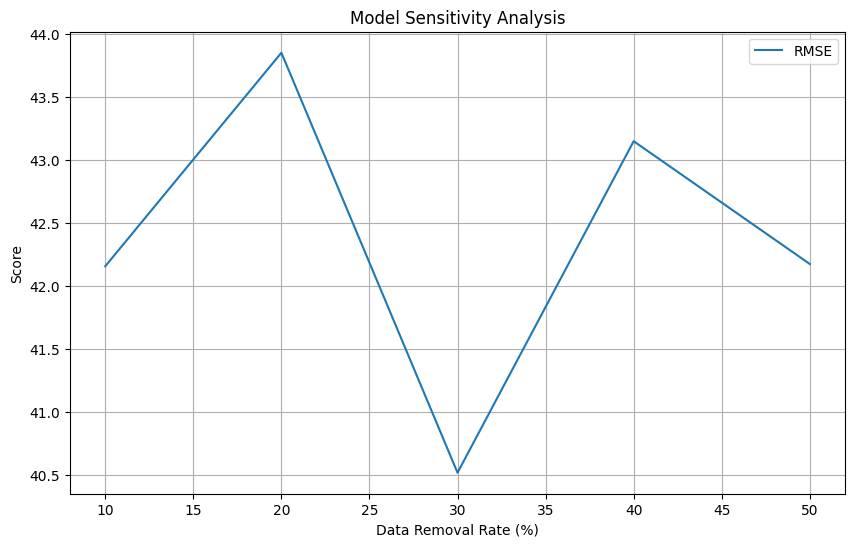

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(removal_rates, rmse_scores, label='RMSE')
plt.title('Model Sensitivity Analysis')
plt.xlabel('Data Removal Rate (%)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()